## Q9.What is the overall distribution of heart rate values?

 Understanding the distribution of heart‑rate values is foundational because it affects every other analysis. Reveals whether heart rate is normal, skewed, or irregular.

In [33]:
import pandas as pd
import glob

# 1. Load all CSV files
df = glob.glob("C:/Users/Owner/Desktop\Harshali/DataAnalyst-Numpy Ninja/Python_Hackython data/Cleandata/*.csv")

# 2. Read each file into a list of DataFrames
dfs = []
for file in cgm_5files_hg:
    temp = pd.read_csv(file)
    dfs.append(temp)

# 3. Merge into one DataFrame
df = pd.concat(dfs, ignore_index=True)

# 4. Heart rate distribution
df['Heart_Rate'].describe()

count    309392.000000
mean         76.990004
std          15.546697
min          32.410000
25%          64.930000
50%          75.420000
75%          85.610000
max         195.620000
Name: Heart_Rate, dtype: float64

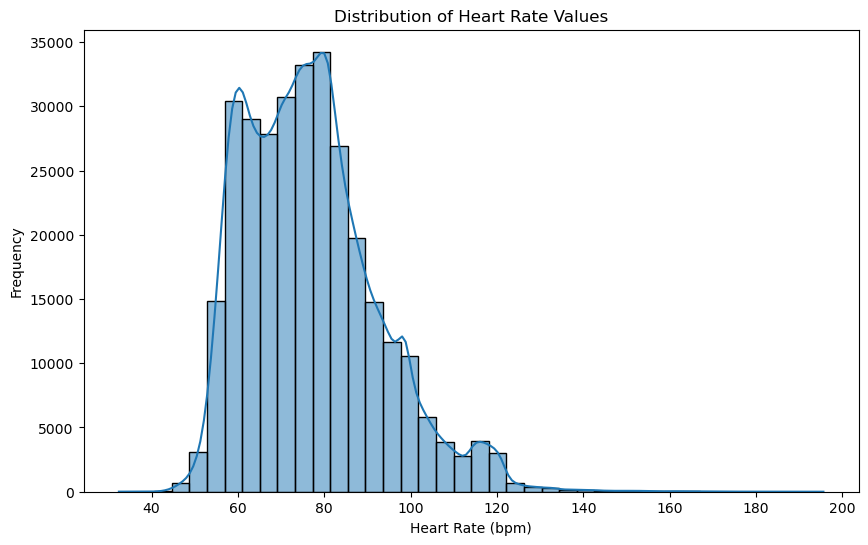

In [40]:
#Heart Rate Distribution Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(df['Heart_Rate'], kde=True, bins=40)
plt.title('Distribution of Heart Rate Values')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.show()

### It shows how stable or unstable heart rate is
- A narrow distribution = stable physiology
- A wide distribution = high variability (stress, activity, dysregulation)
-This matters for:
Risk scoring,
Patient monitoring,
Personalized recommendations.

## Q10 .What are the minimum, maximum, mean, and median heart rate values?

 Core summary statistics for understanding central tendency.These four numbers are not just “basic stats.”They are foundational diagnostics that tell you whether your dataset — and your patients — are behaving normally, abnormally, or dangerously.

In [36]:
df['Heart_Rate'].agg(['min', 'max', 'mean', 'median'])

min        32.410000
max       195.620000
mean       76.990004
median     75.420000
Name: Heart_Rate, dtype: float64

In [37]:
import pandas as pd

# 1. Check column names
print("Columns in the dataset:")
print(df.columns)

# 2. Identify the heart rate column automatically
possible_cols = ['Heart_Rate', 'heart_rate', 'HR', 'HeartRate', 'heart_rate_bpm']

heart_col = None
for col in df.columns:
    if col in possible_cols:
        heart_col = col
        break

if heart_col is None:
    raise ValueError("Heart rate column not found. Please check df.columns and update the column name.")

print(f"\nUsing heart rate column: {heart_col}\n")

# 3. Calculate min, max, mean, median
hr_stats = df[heart_col].agg(['min', 'max', 'mean', 'median'])
print("Heart Rate Statistics:")
print(hr_stats)

Columns in the dataset:
Index(['Patient_ID', 'Age', 'Gender', 'Race', 'Average Sleep Duration (hrs)',
       'Sleep Quality (1-10)', '% with Sleep Disturbances', 'Patient_Id',
       'Time', 'Glucose', 'Calories', 'Heart_Rate', 'Steps', 'Basal_Rate',
       'Bolus_Volume_Delivered', 'Carb_Input'],
      dtype='object')

Using heart rate column: Heart_Rate

Heart Rate Statistics:
min        32.410000
max       195.620000
mean       76.990004
median     75.420000
Name: Heart_Rate, dtype: float64


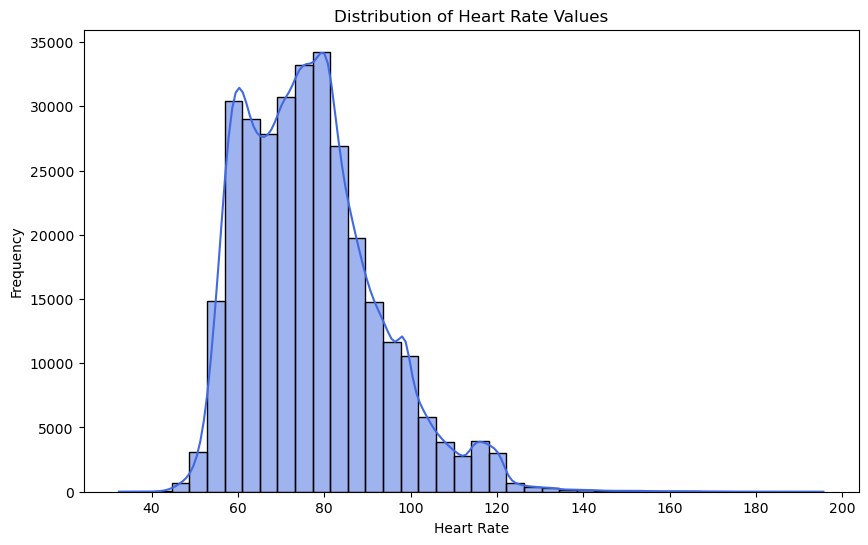

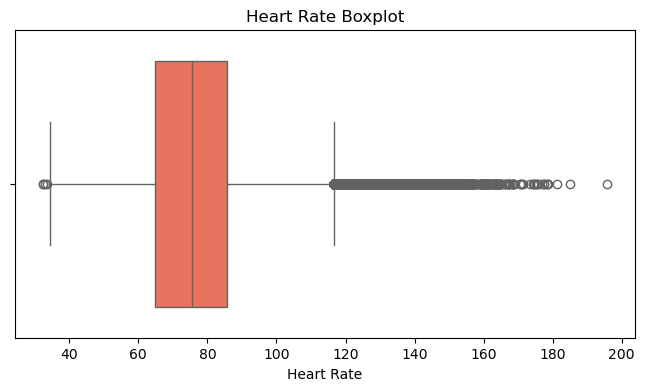

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Histogram + KDE ---
plt.figure(figsize=(10,6))
sns.histplot(df['Heart_Rate'], kde=True, bins=40, color='royalblue')
plt.title('Distribution of Heart Rate Values')
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.show()

# --- 2. Boxplot ---
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Heart_Rate'], color='tomato')
plt.title('Heart Rate Boxplot')
plt.xlabel('Heart Rate')
plt.show()

### Minimum heart rate →
- Detects bradycardia, sleep depth, or device errors
- A very low minimum HR may indicate:
   Deep sleep,
  High fitness,
  Bradycardia,
  Sensor dropouts.
  
If the minimum is too low, it may signal a clinical red flag.

### Maximum heart rate → 
- Detects tachycardia, stress, or activity spikes.
- A high maximum HR may reflect:
Exercise,
Stress,
Fever,
Anxiety,
Arrhythmia,
Device noise.

If the max is extremely high, it may require follow‑up.

### Mean heart rate → 
- Overall cardiovascular load.
- The mean HR is a powerful indicator of:
Fitness level,
Stress load,
Autonomic balance,
Cardiovascular risk.

A high mean HR is associated with higher long‑term mortality risk in clinical literature.

### Median heart rate → 
- Robust central tendency
- The median tells you the “typical” HR without being distorted by spikes.
- If mean ≠ median, the distribution is skewed, which means:
Many spikes,
Many dips,
High variability,
Possible sensor noise.

This helps you decide whether to use mean‑based or median‑based metrics.